In [2]:
# imPORT LIBRARIES 
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from math import pi, sqrt
import handcalcs.render
import pandas as pd
import json 
# !pip install handcalcs

In [3]:
%%render 
Lr = 21e-6 #uH
Lm = 83e-6 # uH
Cr = 120e-9
Ln= Lm/Lr
Fr= 1/(2*pi*sqrt(Lr*Cr))


<IPython.core.display.Latex object>

In [4]:
%%render 
n=4
Rload=22
Re = 8*n**2*Rload / (pi**2)

Qe = sqrt(Lr/Cr)/Re

<IPython.core.display.Latex object>

In [5]:
n=2
Re = n**2*1963

Qe = sqrt(Lr/Cr)/Re
Qe

0.001684762678976433

In [6]:
5.0E-1

0.5

In [7]:
# Charge = 1963 ohm 
t= """Freq khz	CH1pp	CH2pp
162.1	8.45	6.52
151.7	8.25	6.46
139.9	7.95	6.42
129.4	7.65	6.34
121.3	7.4	6.22
109.9	7.2	6.12
101.7	6.65	6
90.93	6	5.76
80.99	5.02	5.52
70.35	3.98	5.22
61.25	2.78	4.8
50	1.11	4.24
47	0.42	4
42	1.05	3.52
37	2.2	3.12""".split("\n")
t= [x.split('\t') for x in t]
df= pd.DataFrame(t[1:], columns = t[0])
df = df.astype("float32")
df["G"]= df["CH2pp"]/df["CH1pp"]
df['Load_ohm']= 1963
dfa1=df.copy()
df

,Freq khz,CH1pp,CH2pp,G,Load_ohm
0,162.100006,8.45,6.52,0.771598,1963
1,151.699997,8.25,6.46,0.783030,1963
2,139.899994,7.95,6.42,0.807547,1963
3,129.399994,7.65,6.34,0.828758,1963
4,121.300003,7.40,6.22,0.840541,1963
5,109.900002,7.20,6.12,0.850000,1963
6,101.699997,6.65,6.00,0.902256,1963
7,90.930000,6.00,5.76,0.960000,1963
8,80.989998,5.02,5.52,1.099602,1963
9,70.349998,3.98,5.22,1.311558,1963


<Axes: xlabel='Freq khz'>

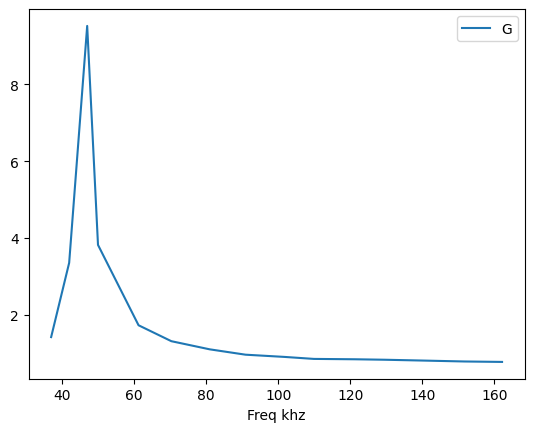

In [8]:
df.plot(x="Freq khz", y="G")

In [9]:
# Charge = 1963 ohm 
t= """Freq khz	CH1pp	CH2pp
160.6	5.3	3.74
151.8	5.2	3.74
141.4	5.05	3.78
131.3	4.85	3.74
121.6	4.46	3.76
110	4.2	3.78
101.2	4	3.72
90.55	3.72	3.66
80.42	3.28	3.64
70.31	2.8	3.52
61.93	2.24	3.44
52.38	1.48	3.05
49.74	1.45	2.99
42.19	1.89	2.69
36.3	2.86	2.38""".split("\n")
t= [x.split('\t') for x in t]
df= pd.DataFrame(t[1:], columns = t[0])
df = df.astype("float32")
df["G"]= df["CH2pp"]/df["CH1pp"]
df['Load_ohm']= 10.1
dfa2=df.copy()
df

,Freq khz,CH1pp,CH2pp,G,Load_ohm
0,160.600006,5.30,3.74,0.705660,10.1
1,151.800003,5.20,3.74,0.719231,10.1
2,141.399994,5.05,3.78,0.748515,10.1
3,131.300003,4.85,3.74,0.771134,10.1
4,121.599998,4.46,3.76,0.843049,10.1
5,110.000000,4.20,3.78,0.900000,10.1
6,101.199997,4.00,3.72,0.930000,10.1
7,90.550003,3.72,3.66,0.983871,10.1
8,80.419998,3.28,3.64,1.109756,10.1
9,70.309998,2.80,3.52,1.257143,10.1


In [10]:
#dfa["Freq khz"]
def calculate_Mg(Ln, fn, Qe):
    numerator = Ln * fn**2
    denominator_real = (Ln + 1) * fn**2 - 1
    denominator_imag = (fn**2 - 1) * fn * Qe * Ln
    denominator = np.sqrt(denominator_real**2+ denominator_imag**2)
    Mg = abs(numerator / denominator)
    return Mg
fn = dfa1["Freq khz"]/100
#Lnc=3 
#Qe = 0.55 
Mg= calculate_Mg(Ln=3.66, fn=fn, Qe=Qe)
#plt.plot(fn, Mg)
#dfa=pd.concat([dfa1,dfa2])
dfa1["MgTheo2"] = Mg

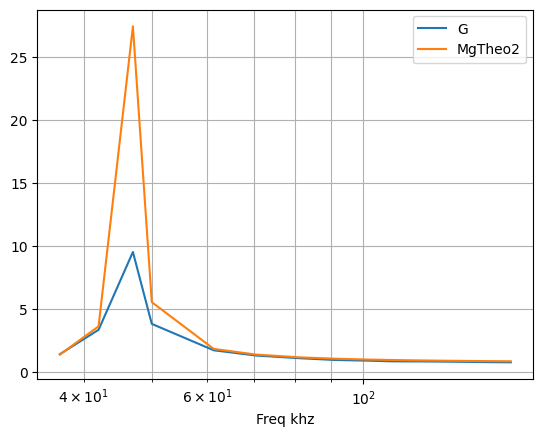

In [11]:

import seaborn as sns
dfa1.plot( x='Freq khz', y=["G","MgTheo2"])
#sns.lineplot(data= dfa1, x='Freq khz', y="MgTheo2", hue = "Load_ohm")

plt.xscale("log")
plt.grid(which = "both")


In [12]:
Vin = 345
t= """155	37.3
147	37.7
121	38.55
110.9	40.48
91.25	44.19
79.91	47.02
77.83	48.88""".split("\n")

n=4


t=[x.split("\t") for x in t]
df35= pd.DataFrame(t, columns =["F", "Vout"]).astype("float32")
df35["F"]=df35["F"]*1000
df35["Mg"]= n*df35["Vout"]/(Vin /2)
df35["fn"]= df35["F"]/Fr
df35

,F,Vout,Mg,fn
0,155000.0,37.299999,0.864928,1.546008
1,147000.0,37.700001,0.874203,1.466214
2,121000.0,38.549999,0.893913,1.206884
3,110900.0,40.480000,0.938667,1.106144
4,91250.0,44.189999,1.024696,0.910150
5,79910.0,47.020000,1.090319,0.797042
6,77830.0,48.880001,1.133449,0.776296


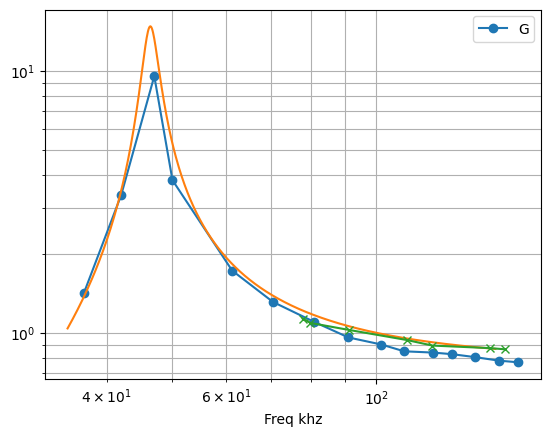

In [16]:
fn = np.arange(0.35,1.5,0.001)
#Lnc=3 
#Qe = 0.55 
Mg= calculate_Mg(Ln=3.66, fn=fn, Qe=0.04)


dfa1.plot( x='Freq khz', y="G", marker = "o")
#sns.lineplot(data= dfa1, x='Freq khz', y="MgTheo2", hue = "Load_ohm")
plt.plot(fn*100, Mg)
plt.xscale("log")
plt.yscale("log")
plt.grid(which = "both")
plt.plot(df35.F/1000, df35.Mg, marker = "x")

In [17]:
P=2200
V=220
R = V**2/P# P = V**2/R
I = P/V
U48=48
(R, I , R*I**2, U48/R, U48**2/R)

(22.0, 10.0, 2200.0, 2.1818181818181817, 104.72727272727273)

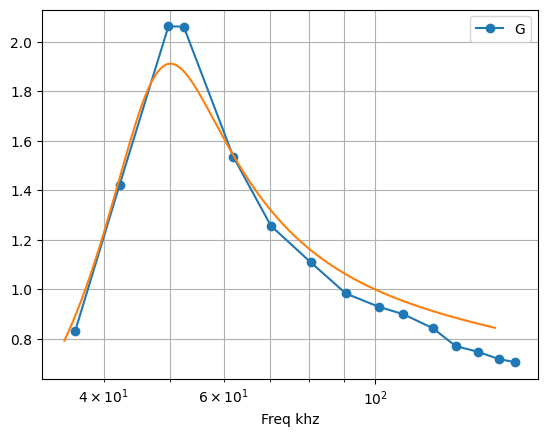

In [18]:
fn = np.arange(0.35,1.5,0.001)
#Lnc=3 
#Qe = 0.55 
n=2
Re = n**2*10.1

Qe = sqrt(Lr/Cr)/Re

Mg= calculate_Mg(Ln=3.66, fn=fn, Qe=Qe)


dfa2.plot( x='Freq khz', y="G", marker = "o")
#sns.lineplot(data= dfa1, x='Freq khz', y="MgTheo2", hue = "Load_ohm")
plt.plot(fn*100, Mg)
plt.xscale("log")
plt.grid(which = "both")

In [19]:
t= """kHz	Vpp	mA	CH2->CH1 °
160.3	3.29	343	-87.29
138.6	2.55	353	-90.53
120.5	1.84	357	-97.59
110.2	1.35	360	-102.6
100.7	0.805	360	-99.75
86.57	0.375	363	-119.6
81.58	0.52	362	94.11
60.5	2.04	359	92.17""".split("\n")
t= [x.split('\t') for x in t]
df= pd.DataFrame(t[1:], columns = t[0])
df = df.astype("float32")
df["Z"]= 1e3*df["Vpp"]/df["mA"]
df

,kHz,Vpp,mA,CH2->CH1 °,Z
0,160.300003,3.290,343.0,-87.290001,9.591837
1,138.600006,2.550,353.0,-90.529999,7.223796
2,120.500000,1.840,357.0,-97.589996,5.154062
3,110.199997,1.350,360.0,-102.599998,3.750000
4,100.699997,0.805,360.0,-99.750000,2.236111
5,86.570000,0.375,363.0,-119.599998,1.033058
6,81.580002,0.520,362.0,94.110001,1.436464
7,60.500000,2.040,359.0,92.169998,5.682451


In [22]:
Cr, Lr

(1.2e-07, 2.1e-05)

In [20]:
f = df.kHz.values*1e3
w = f*2*pi
A = Lr*w-1/(Cr*w)
Z = np.abs(A)
phase =np.sign(A)*90

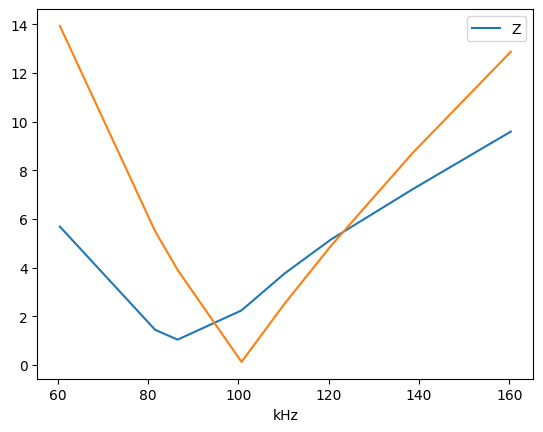

In [21]:
df.plot(x= "kHz", y= "Z")
plt.plot(f/1e3, Z)


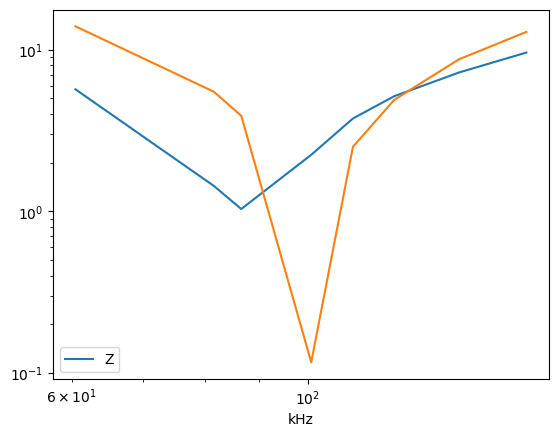

In [24]:
df.plot(x= "kHz", y= "Z")
plt.plot(f/1e3, Z)
plt.xscale("log")
plt.yscale("log")

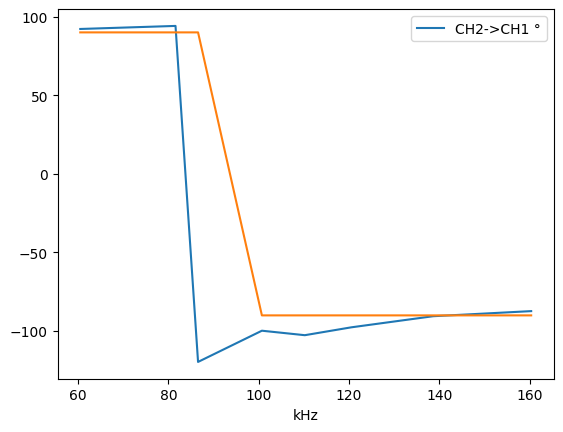

In [16]:
df.plot(x= "kHz", y= "CH2->CH1 °")
plt.plot(f/1e3, -phase)

In [20]:
dfa1
# CH1 'PROBe': '5.0E-1\n',

,Freq khz,CH1pp,CH2pp,G,Load_ohm,MgTheo2
0,162.100006,8.45,6.52,0.771598,1963,0.855253
1,151.699997,8.25,6.46,0.783030,1963,0.866177
2,139.899994,7.95,6.42,0.807547,1963,0.882126
3,129.399994,7.65,6.34,0.828758,1963,0.900860
4,121.300003,7.40,6.22,0.840541,1963,0.919515
5,109.900002,7.20,6.12,0.850000,1963,0.955103
6,101.699997,6.65,6.00,0.902256,1963,0.991023
7,90.930000,6.00,5.76,0.960000,1963,1.060699
8,80.989998,5.02,5.52,1.099602,1963,1.167290
9,70.349998,3.98,5.22,1.311558,1963,1.386656


In [22]:
with open ("2026-01-09_14-56-06-802.txt") as f:
    txt = f.read()
import ast
data = ast.literal_eval(txt)

In [44]:
l=[]
for c in data.keys():
    dic = {}
    if "CH" in c:
        keys = data[c].keys()
        for k in keys: 
            if k != 'raw_data':
                #dic[c+"_"+k]= data[c] [k]
                dic[k]= data[c] [k]
        
        l.append(dic)
                
pd.DataFrame(l).T

,0,1
BANDWIDTH,FULL\n,FULL\n
COUPLING,AC\n,AC\n
IMPEDANCE,MEG\n,MEG\n
INVERT,0\n,0\n
OFFSET,0.0E0\n,0.0E0\n
POSITION,-4.0E-2\n,-2.0E-2\n
PROBe,5.0E-1\n,1.0E0\n
SCALE,1.0E0\n,1.0E0\n
channel,CH1,CH2
x_increment,4.0E-9\n,4.0E-9\n


In [51]:
# CH1 = 5.0E-1
# CH2 = 1.0E0


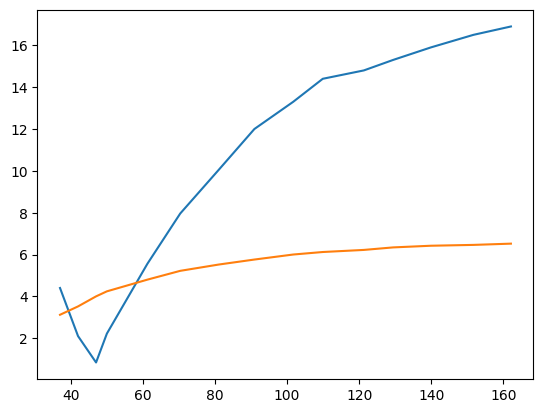

In [55]:
Vch1 = dfa1.CH1pp*(1/5.0E-1)
Vch2 = dfa1.CH2pp*(1/1.0E0)
plt.plot(dfa1["Freq khz"], Vch1)
plt.plot(dfa1["Freq khz"],Vch2)
# Np = 4 
# Ns = 2 (Comp) 
# So ok 